# (08) iP-VAE: fit w/ grad

project = ```iP-VAE```, host = ```solo```, device = ```cuda:1```

**Motivation**: <br>

Same: do not have separate log_lr for each neuron. Just have a global parameter for all.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: solo

## Trainer

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'grad|lin')
cfg_vae['seq_len'] = 64
cfg_vae['n_iters'] = 1

cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 48.0

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.0001, 'seq_len': 64, 'n_iters': 1, 'track_stats': True}

Trainer:
{'batch_size': 200, 'epochs': 300, 'optimizer_kws': {'weight_decay': 0.0}, 'grad_clip': 200, 'kl_beta': 48.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.9 K   |
|     ———     |    ———     |
|    layer    |  132.9 K   |
+-------------+------------+

poisson_vH16_t-64×1_b-1_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(48:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_09,12:54)

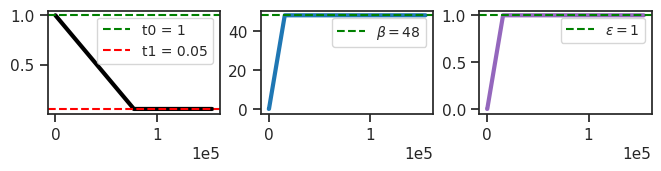

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer)

PoissonLayer(input_dim=256,latent_dim=512, beta_inner=1, temp=1)

In [6]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 300, avg loss: 107.675247: 100%|██| 300/300 [14:22:22<00:00, 172.47s/it]


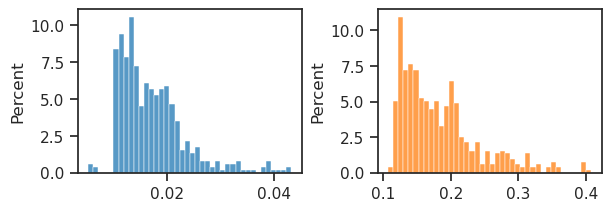

In [9]:
fig, axes = create_figure(1, 2)

kws = dict(bins=40, stat='percent')
sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', ax=axes[0], **kws)
sns.histplot(tonp(tr.model.layer.log_lr.squeeze().exp()), label='lr', color='C1', ax=axes[1], **kws)
ax.legend()
plt.show()

In [10]:
u_min = np.asarray(tr.model.stats['u_min'])
u_max = np.asarray(tr.model.stats['u_max'])
du_min = np.asarray(tr.model.stats['du_min'])
du_max = np.asarray(tr.model.stats['du_max'])

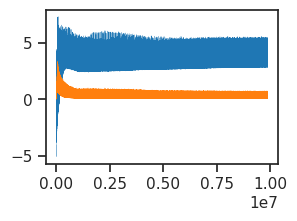

In [11]:
plot(u_max, lw=0.2)
plot(du_max, lw=0.2)

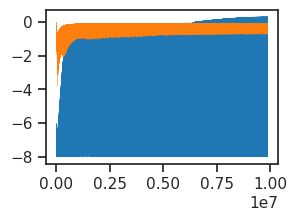

In [12]:
plot(u_min, lw=0.2)
plot(du_min, lw=0.2)

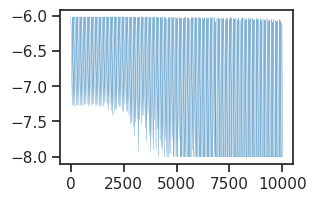

In [13]:
plot(u_min[:10000], lw=0.2)

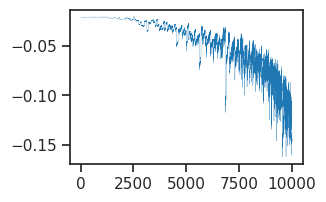

In [14]:
plot(du_min[:10000], lw=0.2)

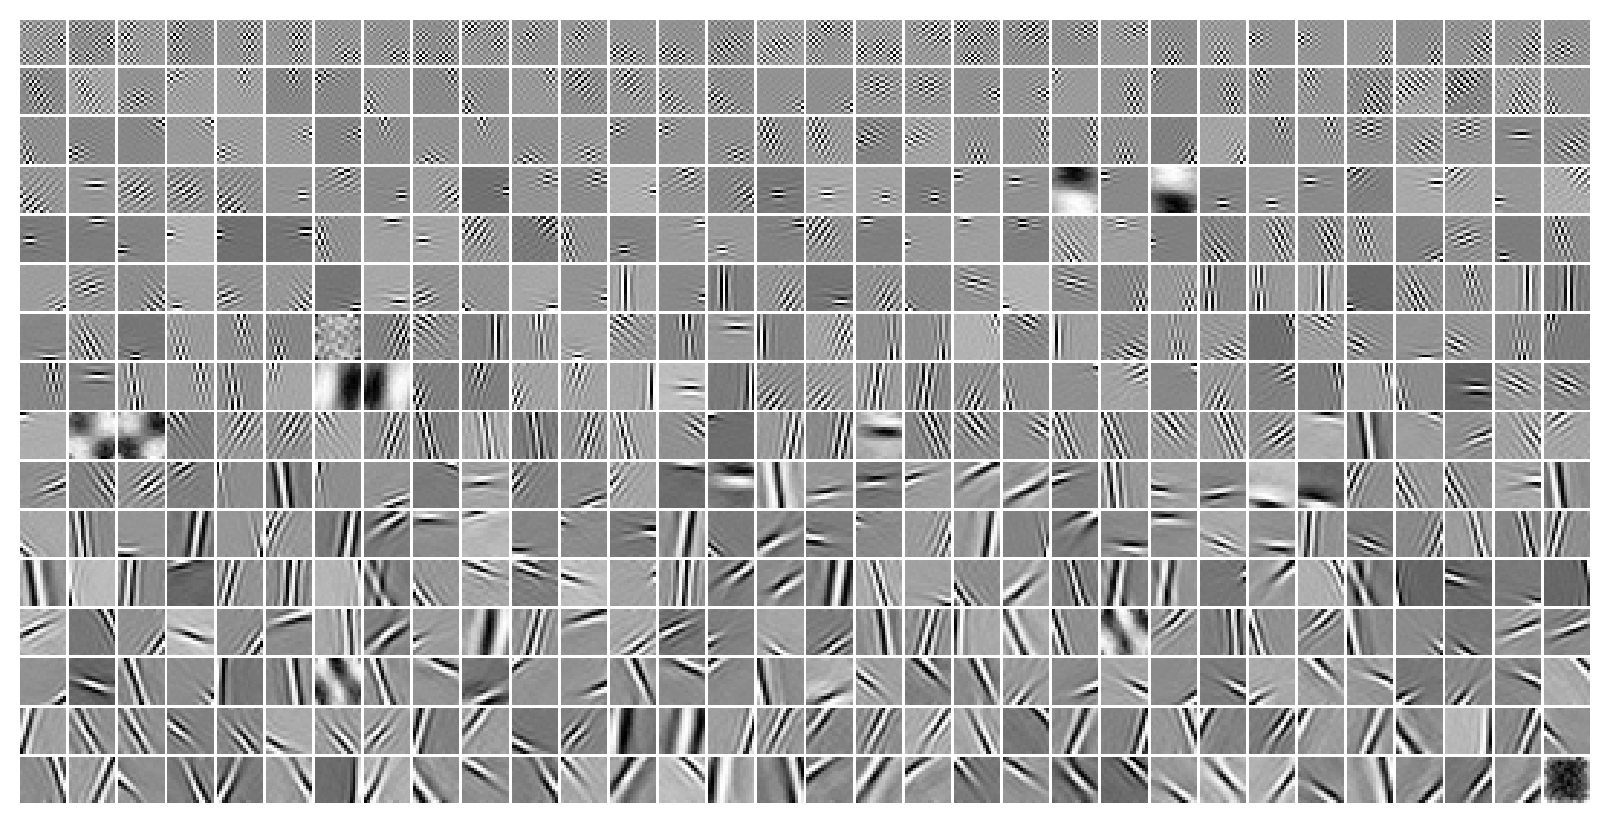

In [15]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

In [16]:
%%time

feeder = tr.get_feeder(next(iter(tr.dl_vld))[0])
output = tr.model.xtract_ftr(feeder, seq=range(1000), return_extras=True).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'u', 'v', 'recon', 'samples', 'conditional']

CPU times: user 2.37 s, sys: 73.2 ms, total: 2.45 s
Wall time: 2.45 s


In [17]:
u_norm = torch.linalg.norm(output['u'], axis=-1)
r_norm = torch.linalg.norm(torch.exp(output['u']), axis=-1)
# v_norm = torch.linalg.norm(output['v'], axis=-1)
# a_norm = torch.linalg.norm(output['a'], axis=-1)

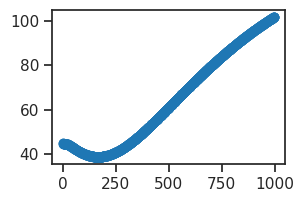

In [18]:
plot(u_norm.mean(0), marker='o');

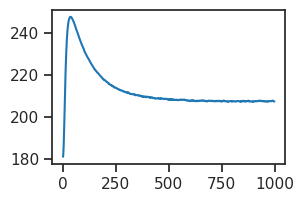

In [19]:
plot(r_norm.mean(0));

[0.7638876438140869,
 0.7643042206764221,
 0.7642691135406494,
 0.7638776302337646,
 0.7650191783905029]

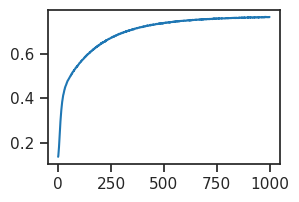

In [20]:
from analysis.sparse import sparse_score


t = 0
lifetime, population = [], []
for t in range(output['samples'].shape[1]):
    life, popu, _ = sparse_score(output['samples'][:, t, :])
    lifetime.append(life.mean().item())
    population.append(popu.mean().item())


plt.plot(lifetime);
lifetime[-5:]

tensor([9.8772, 9.9833, 9.8880, 9.8905, 9.9771], device='cuda:1')

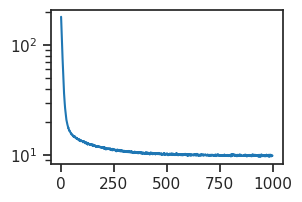

In [21]:
locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log');

mse.mean(0)[-5:]

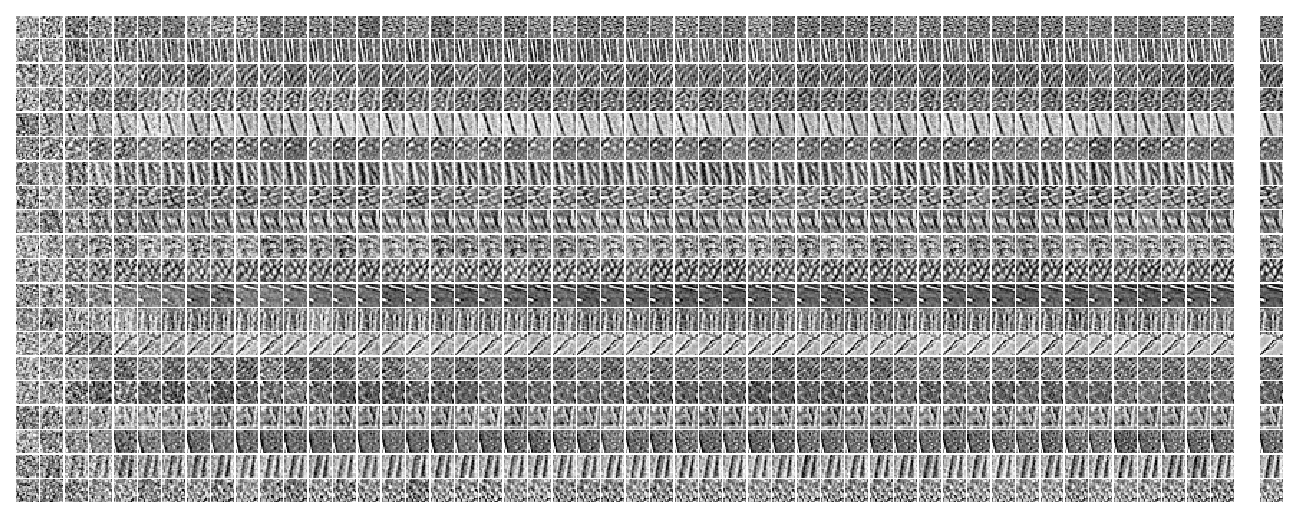

In [22]:
num = 20
n_timepoints = 50
x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

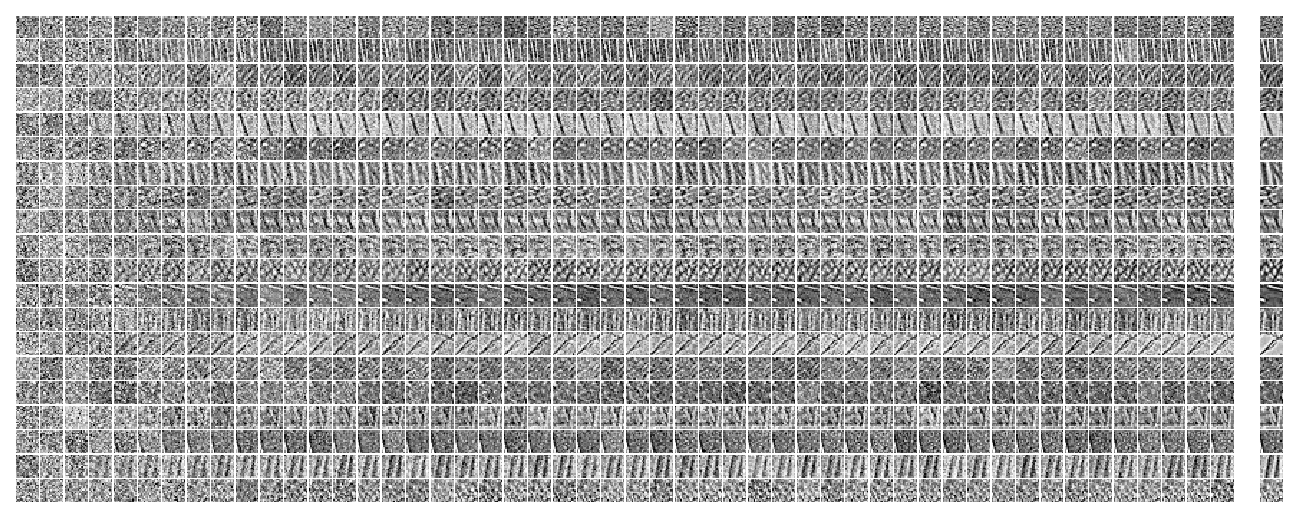

In [23]:
num = 20
n_timepoints = 50
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

tensor([0.2626, 0.2695, 0.2679, 0.2610, 0.2614], device='cuda:1')

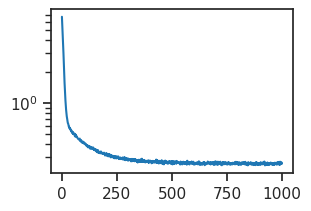

In [24]:
fig, ax = create_figure()

x2p = output['loss_kl'].sum(-1).mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([9.8772, 9.9833, 9.8880, 9.8905, 9.9771], device='cuda:1')

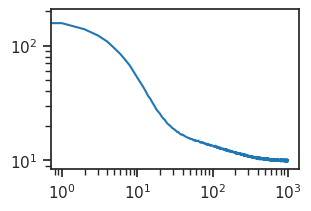

In [25]:
fig, ax = create_figure()

x2p = mse.mean(0)
plot(x2p)
ax.set(xscale='log', yscale='log');

x2p[-5:]